# Đề bài 3: Phân Tích Năng Suất Và Sự Hài Lòng Của Nhân Viên
# CHUẨN BỊ DỮ LIỆU
*   Import thư việc, file data
*   Làm sạch
*   Tạo cột mới








**1.   Import thư viện và file data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [2]:
file_path = "/content/hr_dashboard_data.csv"

df_raw = pd.read_csv(file_path)
print("Shape ban dau:", df_raw.shape)
print("So gia tri missing:", int(df_raw.isna().sum().sum()))

Shape ban dau: (200, 11)
So gia tri missing: 0


In [3]:
# CHECK RAW DATA
df_raw.info()
# display(df_raw.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   200 non-null    object 
 1   Age                    200 non-null    int64  
 2   Gender                 200 non-null    object 
 3   Projects Completed     200 non-null    int64  
 4   Productivity (%)       200 non-null    int64  
 5   Satisfaction Rate (%)  200 non-null    int64  
 6   Feedback Score         200 non-null    float64
 7   Department             200 non-null    object 
 8   Position               200 non-null    object 
 9   Joining Date           200 non-null    object 
 10  Salary                 200 non-null    int64  
dtypes: float64(1), int64(5), object(5)
memory usage: 17.3+ KB


**2.   Làm sạch dữ liệu**



In [4]:
# Chuyển Joining Date sang date
df_raw['Joining Date'] = pd.to_datetime(df_raw['Joining Date'], format='%b-%y')

# Loại bỏ duplicate dựa trên "Name"
df = df_raw.drop_duplicates(subset=['Name'])

In [5]:
# Check missing "Salary"
df_raw['Salary'].isnull().sum()

np.int64(0)

=> Không có giá trị salary bị missing => không cần xử lý

**3.   Tạo cột mới**

In [6]:
# Tạo cột "Experience Years"
today = pd.to_datetime('today')
df['Experience Years'] = (today - df['Joining Date']).dt.days / 365

# Tạo cột Productivity Group
def productivity_group(x):
    if x < 50:
        return 'Low'
    elif x <= 80:
        return 'Medium'
    else:
        return 'High'

df['Productivity Group'] = df_raw['Productivity (%)'].apply(productivity_group)


# KHÁM PHÁ DỮ LIỆU
*   Trung bình Productivity theo Department, Tương quan giữa Satisfaction Rate và Feedback Score.

*    Mối liên hệ giữa Age và Projects Completed, phân bố theo Gender hoặc Position.



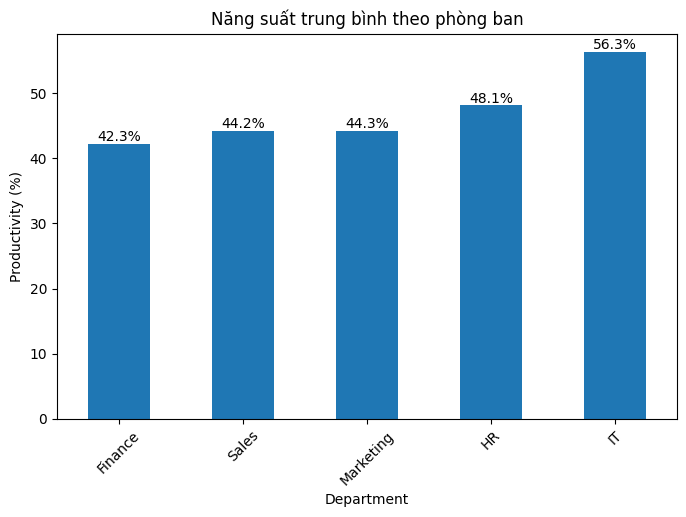

In [7]:
# Trung bình Productivity theo Department
department_avg_productivity = df.groupby('Department')['Productivity (%)'].mean().sort_values()

plt.figure(figsize=(8,5))

ax = department_avg_productivity.plot(kind='bar')

for i, value in enumerate(department_avg_productivity):
    ax.text(i, value, f"{value:.1f}%", ha='center', va='bottom')

plt.title('Năng suất trung bình theo phòng ban')
plt.xlabel('Department')
plt.ylabel('Productivity (%)')
plt.xticks(rotation=45)

plt.show()

=> Năng suất có sự khác biệt đáng kể giữa các phòng ban, trong đó IT dẫn đầu rõ rệt.

Tuy nhiên, sự khác biệt về tính chất công việc cần được xem xét trước khi so sánh trực tiếp. Cần phân tích thêm mối quan hệ giữa năng suất và mức độ hài lòng để đánh giá tính bền vững của hiệu suất.

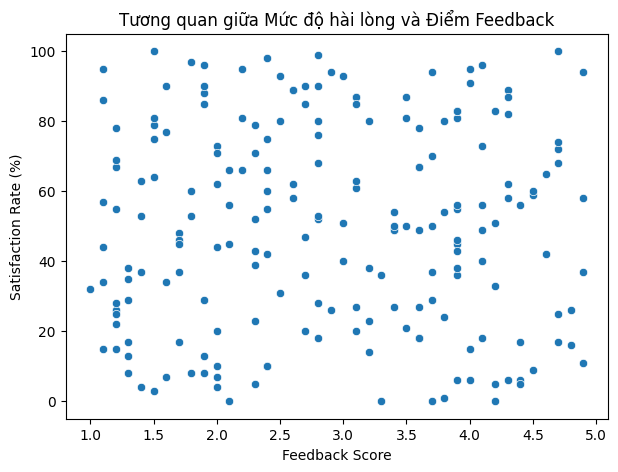

In [8]:
# Tương quan giữa mức độ hài lòng của nhân viên với điểm feedback
plt.figure(figsize=(7,5))
sns.scatterplot(x='Feedback Score', y='Satisfaction Rate (%)', data=df)

plt.title('Tương quan giữa Mức độ hài lòng và Điểm Feedback')
plt.show()

In [9]:
# Hệ số tương quan giữa Feedback Score và Satisfaction Rate
corr = df['Feedback Score'].corr(df['Satisfaction Rate (%)'])
print(f'Hệ số tương quan: {corr:.2f}')

Hệ số tương quan: 0.01


* Không tìm thấy mối tương quan đáng kể giữa Feedback Score và Satisfaction Rate

* Hệ số tương quan gần như bằng 0 (≈ 0.01)

  => Cho thấy hệ thống feedback hiện tại chưa phản ánh chính xác trải nghiệm thực tế của nhân viên, hoặc chưa phải là yếu tố chính ảnh hưởng đến sự hài lòng.

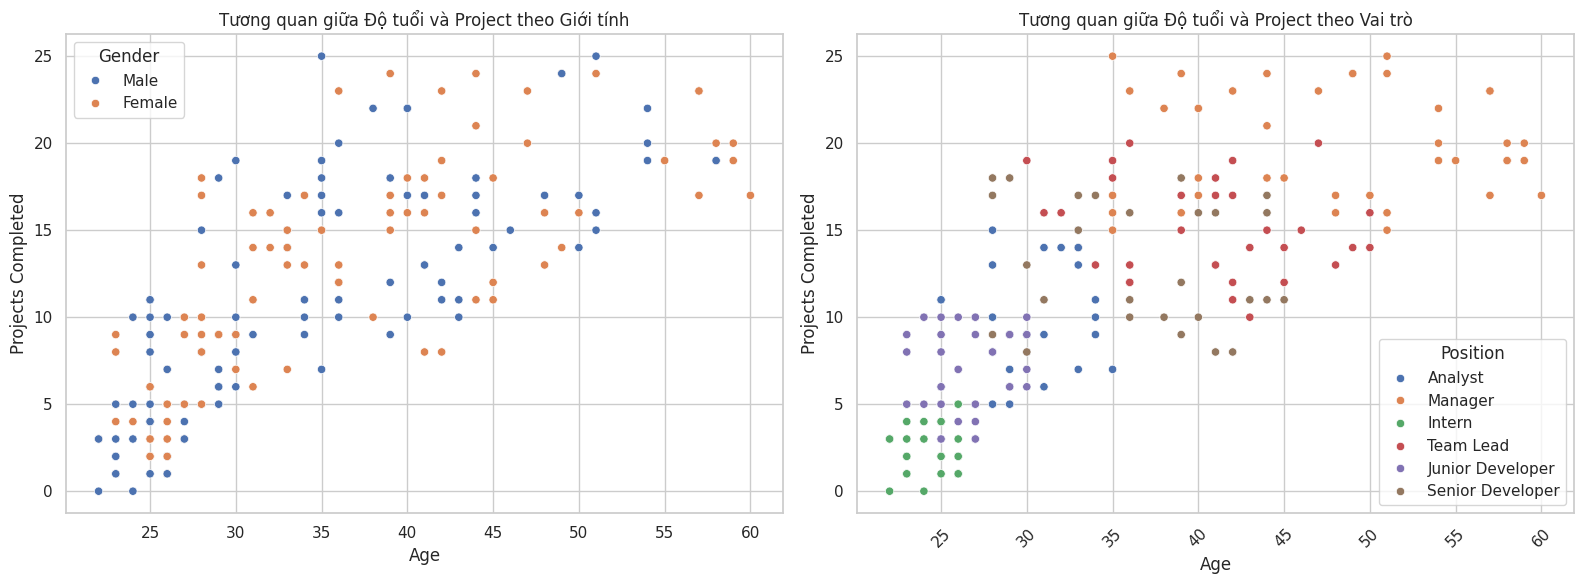

In [10]:
# Mối liên hệ giữa Age và Projects Completed, phân bố theo Gender hoặc Position
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Gender
sns.scatterplot(x='Age',y='Projects Completed',hue='Gender',data=df,ax=axes[0])
axes[0].set_title('Tương quan giữa Độ tuổi và Project theo Giới tính')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Projects Completed')

# Position
sns.scatterplot(x='Age', y='Projects Completed', hue='Position', data=df, ax=axes[1])
axes[1].set_title('Tương quan giữa Độ tuổi và Project theo Vai trò')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Projects Completed')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* Dữ liệu cho thấy tương quan dương giữa Age và Projects Completed => nhân viên lớn tuổi thường hoàn thành nhiều dự án hơn

* Không có sự khác biệt đáng kể theo giới tính => năng suất đồng đều giữa các giới

* Trong khi đó, Position thể hiện sự khác biệt rõ ràng: các vị trí cấp cao (Senior, Manager) gắn với độ tuổi lớn hơn và số lượng dự án cao hơn => phản ánh xu hướng phát triển theo kinh nghiệm.








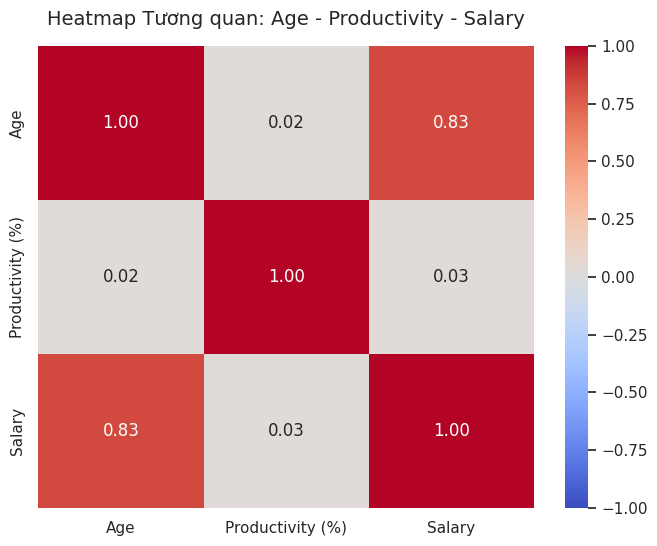

In [11]:
plt.figure(figsize=(8, 6))
# Lọc ra 3 cột cần tính tương quan và tính ma trận tương quan (Pearson)
corr_matrix = df[['Age', 'Productivity (%)', 'Salary']].corr()
# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
# Định dạng biểu đồ
plt.title('Heatmap Tương quan: Age - Productivity - Salary', fontsize=14, pad=15)
plt.show()

Salary có tương quan mạnh với Age (r=0.83), cho thấy xu hướng trả lương theo thâm niên.

Tuy nhiên, Productivity gần như không có mối liên hệ với cả Age và Salary:
*   Salary – Productivity (r = 0.03)
*   Age – Productivity (r = 0.02)

=> hiệu suất làm việc có thể bị chi phối bởi các yếu tố khác như kỹ năng, môi trường, quản lý.

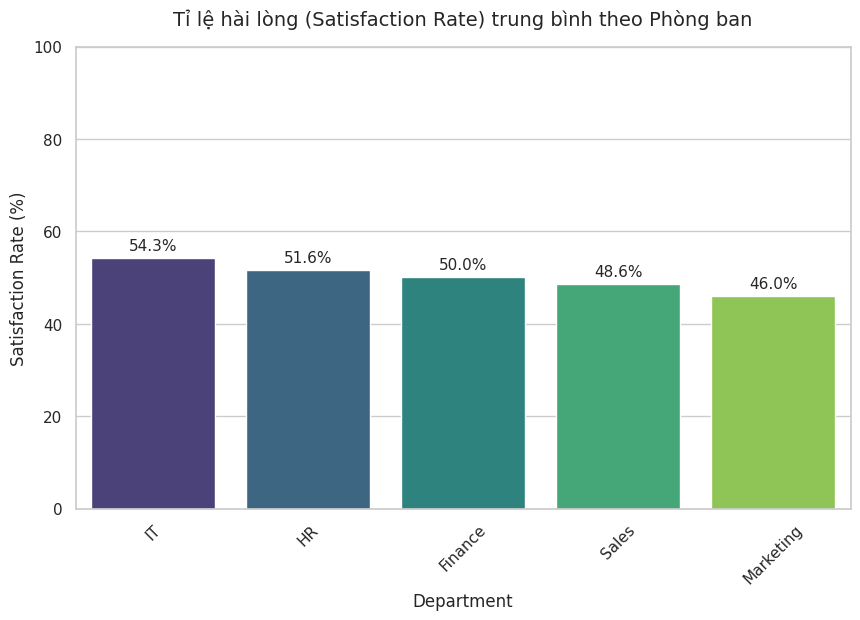

In [12]:
plt.figure(figsize=(10, 6))

# Tính trung bình Satisfaction Rate theo từng phòng ban và sắp xếp giảm dần
dept_satisfaction = df.groupby('Department')['Satisfaction Rate (%)'].mean().sort_values(ascending=False).reset_index()

# Vẽ Bar chart
sns.barplot(x='Department', y='Satisfaction Rate (%)', data=dept_satisfaction, palette='viridis', hue='Department', legend=False)

# Thêm số liệu lên đầu các cột
for index, value in enumerate(dept_satisfaction['Satisfaction Rate (%)']):
    plt.text(index, value + 1, f"{value:.1f}%", ha='center', va='bottom', fontsize=11)

# Định dạng biểu đồ
plt.title('Tỉ lệ hài lòng (Satisfaction Rate) trung bình theo Phòng ban', fontsize=14, pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Satisfaction Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.show()

* Phòng có mức độ hài lòng cao nhất ~54%, trong khi Marketing thấp nhất ~46%
* Khoảng cách giữa các phòng ban là tương đối nhỏ ~8%

  => trải nghiệm nhân viên ở công ty khá đồng đều


In [13]:
# Tính trung bình mức độ hài lòng và năng suất theo từng phòng
df.groupby('Department')[['Productivity (%)', 'Satisfaction Rate (%)']].mean().sort_values(by='Satisfaction Rate (%)', ascending=True)

,Productivity (%),Satisfaction Rate (%)
Department,,
Marketing,44.261905,46.023810
Sales,44.212766,48.617021
Finance,42.268293,50.048780
HR,48.125000,51.625000
IT,56.342105,54.342105


* IT đạt cả mức độ hài lòng và năng suất cao
* Marketing và Sales có hiệu suất thấp đi kèm mức độ hài lòng thấp => rủi ro về hiệu quả vận hành và cần ưu tiên cải thiện
* Finance có mức độ hài lòng tương đối tốt nhưng năng suất thấp, => có khả năng tồn tại “comfort zone” và cần xem xét lại cơ chế đánh giá hiệu suất

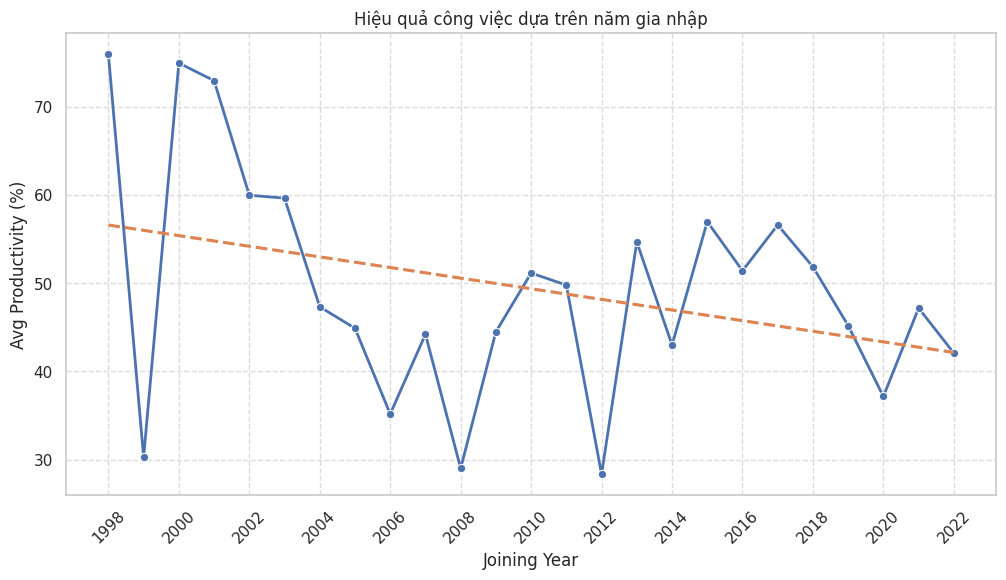

In [14]:
# Convert sang datetime
df['Joining Date'] = pd.to_datetime(df['Joining Date'])

# Extract year
df['Joining Year'] = df['Joining Date'].dt.year

# Group theo năm
prod_trend = (df.groupby('Joining Year')['Productivity (%)'].mean()
.reset_index())

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(x='Joining Year',y='Productivity (%)',data=prod_trend,marker='o',
    linewidth=2)

sns.regplot(
    x='Joining Year',
    y='Productivity (%)',
    data=prod_trend,
    scatter=False,
    ci=None,
    line_kws={'linestyle': '--'}
)

plt.title('Hiệu quả công việc dựa trên năm gia nhập')
plt.xlabel('Joining Year')
plt.ylabel('Avg Productivity (%)')
plt.grid(True, linestyle='--', alpha=0.7)
years = prod_trend['Joining Year']
plt.xticks(years[::2], rotation=45)

plt.show()

* Có sự khác biệt rõ rệt về năng suất giữa các thời điểm gia nhập khác nhau.
* Các thời điểm gia nhập trước 2004 có xu hướng năng suất cao hơn.
* Một số năm như 1999, 2008, 2012 và 2020 xuất hiện mức giảm mạnh => khả năng tồn tại các yếu tố hệ thống ảnh hưởng đến hiệu suất tại các thời điểm đó.
* Thời điểm từ 2013-2022 có xu hướng ổn định, nhưng chưa đạt hiệu suất cao như các thời điểm đầu.

In [15]:
# Lưu file cleaned
df.to_csv('Hr_Dashboard_Data_Cleaned.csv', index=False)

# Tải file về máy tính
from google.colab import files
files.download('Hr_Dashboard_Data_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Chọn features đúng với dataset
features = [
    'Age',
    'Salary',
    'Productivity (%)',
    'Projects Completed',
    'Feedback Score',
    'Experience Years',
    'Gender',
    'Department',
    'Position',
    'Joining Year'
]

X = df[features].copy()
y = df['Satisfaction Rate (%)']

# 2. One-hot encoding (chuẩn hơn LabelEncoder)
X = pd.get_dummies(
    X,
    columns=['Gender', 'Department', 'Position'],
    drop_first=True
)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Scaling (chỉ scale numeric columns)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Đã chuẩn bị xong dữ liệu huấn luyện!")

Đã chuẩn bị xong dữ liệu huấn luyện!


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Predict
y_pred = model.predict(X_test)

# 3. Evaluation (Regression metrics)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"- Sai số trung bình (RMSE): {rmse:.2f}")
print(f"- Độ phù hợp (R2 Score): {r2:.2f}")

- Sai số trung bình (RMSE): 27.00
- Độ phù hợp (R2 Score): 0.20


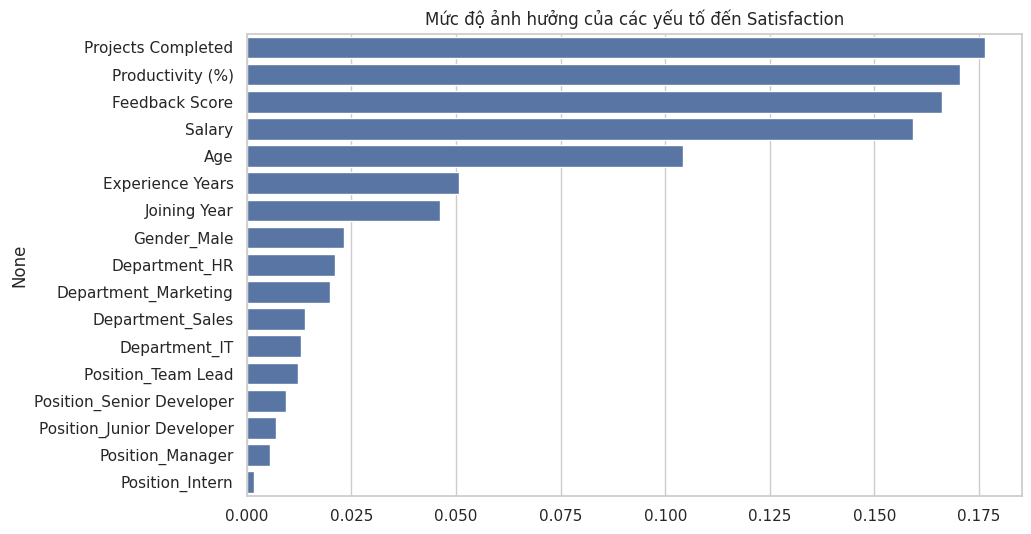


 5 YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT:
Projects Completed    0.176369
Productivity (%)      0.170469
Feedback Score        0.166113
Salary                0.159239
Age                   0.104204
dtype: float64


In [18]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Mức độ ảnh hưởng của các yếu tố đến Satisfaction")
plt.show()

print("\n 5 YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT:")
print(importances.head(5))

## Tóm tắt và Đề xuất

### **Insights Chính:**

1.  **Năng suất theo Phòng ban:**
    *   **IT** dẫn đầu về năng suất, trong khi **Sales**, **Marketing** có năng suất thấp hơn,
    * **Finance** có năng suất thấp nhất.
    *   Do tính chất công việc khác nhau nên cần phân tích thêm các yếu tố khác.

2.  **Ảnh hưởng của Salary đến Satisfaction Rate:**
    *   `Salary` là một trong Top 5 yếu tố ảnh hưởng mạnh nhất đến `Satisfaction Rate (%)` (mức độ quan trọng là 0.159), cho thấy đây là một yếu tố quan trọng tác động đến sự hài lòng của nhân viên.

3.  **Mối liên hệ giữa Sự hài lòng và Feedback:**
    *   Không có tương quan đáng kể giữa `Feedback Score` và `Satisfaction Rate (%)` (hệ số ~0.01), cho thấy hệ thống feedback có thể chưa phản ánh đúng mức độ hài lòng thực tế.

4.  **Tuổi, Dự án và Vị trí:**
    *   Nhân viên lớn tuổi hơn thường hoàn thành nhiều dự án hơn, đặc biệt ở các vị trí cấp cao (`Manager`, `Senior Developer`).
    *   `Gender` không ảnh hưởng đáng kể đến `Projects Completed`.

5.  **Tương quan giữa Age, Productivity và Salary:**
    *   `Salary` tương quan mạnh với `Age` (0.83), cho thấy xu hướng trả lương theo thâm niên.
    *   `Productivity (%)` gần như không có mối liên hệ với `Age` (0.02) và `Salary` (0.03), cho thấy hiệu suất không được phản ánh trực tiếp qua tuổi và lương.

6.  **Mức độ hài lòng theo Phòng ban:**
    *   `IT` có mức độ hài lòng cao nhất (54.34%), trong khi `Marketing` thấp nhất (46.02%). Khoảng cách giữa các phòng ban là tương đối nhỏ (8%), cho thấy trải nghiệm nhân viên khá đồng đều.
    *   Cần ưu tiên phân tích cải thiện các phòng ban năng suất thấp.

7.  **Xu hướng Năng suất theo Năm gia nhập:**
    *   Có sự khác biệt rõ rệt: các nhân viên gia nhập trước 2004 có năng suất cao hơn.
    *   Các năm như 1999, 2008, 2012, 2020 chứng kiến mức giảm năng suất mạnh, cần phân tích nguyên nhân sâu hơn.

8.  **Mô hình Dự đoán Hài lòng (RandomForestRegressor):**
    *   Mô hình có RMSE = 27.00 và R2 Score = 0.20. Các yếu tố quan trọng nhất ảnh hưởng đến `Satisfaction Rate (%)` là `Projects Completed`, `Productivity (%)`, `Feedback Score`, `Salary`, và `Age`.

### **Đề xuất:**

1.  **Chương trình Đào tạo và Phát triển:**
    *   Tập trung vào các phòng ban có năng suất thấp (`Finance`, `Sales`, `Marketing`) để nâng cao kỹ năng và hiệu suất.
    *   Thiết kế các chương trình đào tạo phù hợp cho nhân viên trẻ để đẩy nhanh quá trình tích lũy `Projects Completed` và `Experience Years`.

2.  **Chính sách Lương thưởng:**
    *   Xem xét điều chỉnh chính sách lương để gắn kết tốt hơn với hiệu suất thực tế thay vì chỉ dựa vào thâm niên

3.  **Hệ thống Feedback và Đánh giá:**
    *   Cải thiện hệ thống `Feedback Score` để nó phản ánh chính xác hơn `Satisfaction Rate (%)` và trải nghiệm thực tế của nhân viên.